# Risk Parity Portfolio Construction
**QFGB 8948 — Team Portfolio Project · Page 5: RP Proposal**

Implements five portfolio construction methods on a rolling 36-month estimation window,
using Kalman factor loadings from `kalman_factor_model_v2.ipynb` for Factor ERC.

| Method | Objective (Class 5-3) |
|--------|----------------------|
| **Vol RP** | $w_i = k/\sigma_i$, $k = 1/\sum\sigma_i^{-1}$ — naïve inverse-vol |
| **Covar RP (ERC)** | $\min\sum|\tfrac{1}{N}-\text{TRC}_i|$ s.t. $w'\Sigma w = RB^2$, $w_i\ge 0$ |
| **MDP** | $\max DR_P = \frac{\sum w_i\sigma_i}{\sigma_P}$ s.t. $\sum w_i=1$, $w_i\ge 0$ |
| **HRP** | Hierarchical clustering + recursive 1/var bisection (Lopez de Prado 2018) |
| **Factor ERC** | ERC on Kalman-implied $\hat{\Sigma}=B\Sigma_F B'+\Sigma_\varepsilon$ |

**Benchmark**: Equal-weight (current client portfolio, $w_i=20\%$ each)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.optimize import minimize
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})
np.random.seed(42)

DATA_DIR  = 'PM/'
ROLL_WIN  = 36    # 3-year rolling estimation window
ANN       = 12    # annualisation factor (monthly data)

# Colour palette for all plots
COLORS = {
    'Vol RP'       : 'steelblue',
    'Covar RP'     : 'forestgreen',
    'MDP'          : 'darkorange',
    'HRP'          : 'purple',
    'Factor ERC'   : 'crimson',
    'Equal Weight' : '#888888',
    '60/40'        : '#222222',
}
METHODS = list(COLORS.keys())

---
## 1 · Data Loading

In [ ]:
EXCEL_PATH = '1 Project - Data.xlsx'
Sheet_NAMES = ['Python FULL DATA', 'Python FACTORS']

def _load_assets(path):
    """Load asset returns from 'Python FULL DATA' sheet."""
    df = pd.read_excel(path, sheet_name=Sheet_NAMES[0],
                       header=0, index_col=0)
    df.columns = df.columns.str.strip()
    df.rename(columns={'Asset 3': 'Asset3'}, inplace=True)
    df.index = pd.date_range(start='2004-01-31', periods=len(df), freq='ME')
    df.index.name = 'Date'
    return df

def _load_factors(path):
    """Load factor returns from 'Python FACTORS' sheet (skip ticker/label rows)."""
    df = pd.read_excel(path, sheet_name=Sheet_NAMES[1],
                       header=0, index_col=0, skiprows=[1, 2])
    df.columns = df.columns.str.strip()
    df.index = pd.date_range(start='2004-01-31', periods=len(df), freq='ME')
    df.index.name = 'Date'
    return df

r_all  = _load_assets(EXCEL_PATH)
F_all  = _load_factors(EXCEL_PATH)

# Align to common dates (inner join) - keeps Jan 2004 - Dec 2013 (120 months)
idx   = r_all.index.intersection(F_all.index)
r_all = r_all.loc[idx]
F_all = F_all.loc[idx]
assets = r_all.columns.tolist()
dates  = r_all.index
cash   = F_all['Cash']           # monthly risk-free proxy
T, N   = r_all.shape

# ── per-asset factor selections (from kalman_factor_model_v2.ipynb) ─────────────
ASSET_FACTORS = {
    'Asset 1': ['US AGG', 'US Small Cap', 'High Yield', 'HF FOF Div', 'Gold'],
    'Asset 2': ['US Growth', 'US Tbill 1-3yr', 'High Yield', 'Long Short HF', 'Commodities'],
    'Asset3' : ['Commodities', 'MSCI EM Equity', 'Global AGG', 'High Yield', 'Long Short HF'],
    'Asset 4': ['HF FOF Div', 'MSCI EM Equity', 'Global AGG', 'High Yield', 'Commodities'],
    'Asset 5': ['TIPs', 'MSCI EM Equity', 'US AGG', 'High Yield', 'Relative Value HF'],
}
# Sorted union of all modeled factors (for factor-level TRC)
UNION_FACTORS = sorted({f for flist in ASSET_FACTORS.values() for f in flist})

# ── load Kalman smoothed factor loadings (CSV generated by kalman_factor_model_v2) ──
fl_raw = pd.read_csv('PM/factor_loadings_v2_smoothed.csv',
                     header=[0, 1], index_col=0)
# Drop the 'Date' label row (pandas MultiIndex CSV artifact)
fl_raw = fl_raw[~fl_raw.index.astype(str).str.strip().isin(['Date'])].astype(float)
fl_raw.index = dates

# Build clean per-asset factor loading DataFrames: fl[asset] -> (T x 5)
fl = {}
for asset in assets:
    cols = [(lv0, lv1) for lv0, lv1 in fl_raw.columns if lv0.strip() == asset]
    sub  = fl_raw[cols].copy()
    sub.columns = [lv1 for _, lv1 in sub.columns]
    fl[asset] = sub

print(f'Assets     : {assets}')
print(f'Date range : {dates[0].strftime("%b %Y")} -> {dates[-1].strftime("%b %Y")} ({T} months)')
print(f'Union factors ({len(UNION_FACTORS)}): {UNION_FACTORS}')
print(f'Backtest starts: {dates[ROLL_WIN].strftime("%b %Y")} (first month after 36m init window)')


Assets     : ['Asset 1', 'Asset 2', 'Asset3', 'Asset 4', 'Asset 5']
Date range : Jan 2004 -> Dec 2013 (120 months)
Union factors (13): ['Commodities', 'Global AGG', 'Gold', 'HF FOF Div', 'High Yield', 'Long Short HF', 'MSCI EM Equity', 'Relative Value HF', 'TIPs', 'US AGG', 'US Growth', 'US Small Cap', 'US Tbill 1-3yr']
Backtest starts: Jan 2007 (first month after 36m init window)


---
## 2 · Current (Equal-Weight) Portfolio Overview

=== Full-Sample Asset Statistics (Jan 2004 – Dec 2013) ===


,Home Factor,Ann. Return,Ann. Vol,Sharpe,Min Monthly,Max Monthly
Asset 1,US AGG,4.55%,2.65%,1.120,-1.78%,3.93%
Asset 2,US Growth,8.40%,18.63%,0.366,-17.79%,12.14%
Asset3,Commodities,9.33%,24.96%,0.310,-26.88%,22.18%
Asset 4,HF FOF Div,4.27%,4.86%,0.553,-2.84%,4.22%
Asset 5,TIPs,5.44%,7.13%,0.541,-9.43%,7.21%


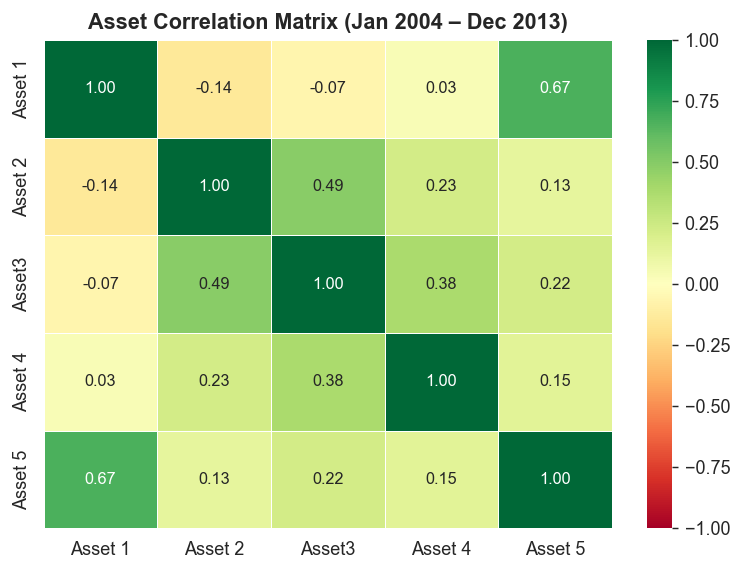


=== Current (Equal-Weight) Portfolio ===
Ann. Return : 6.40%
Ann. Vol    : 8.36%
Sharpe      : 0.576


,Weight,TRC (monthly),% Risk
Asset 1,20.0%,0.0001,0.5%
Asset 2,20.0%,0.0083,34.2%
Asset3,20.0%,0.0127,52.8%
Asset 4,20.0%,0.0013,5.4%
Asset 5,20.0%,0.0017,7.1%


In [4]:
EQ_W     = np.ones(N) / N
cov_full = np.cov(r_all.values.T, ddof=0)  # full-sample population covariance
rf_ann   = cash.mean() * ANN           # annualised risk-free rate

# ── full-sample asset statistics ─────────────────────────────────────────────
mu_ann  = r_all.mean() * ANN
vol_ann = r_all.std()  * np.sqrt(ANN)
sharpe  = (mu_ann - rf_ann) / vol_ann

stat_df = pd.DataFrame({
    'Home Factor'  : [ASSET_FACTORS[a][0] for a in assets],
    'Ann. Return'  : mu_ann.map('{:.2%}'.format),
    'Ann. Vol'     : vol_ann.map('{:.2%}'.format),
    'Sharpe'       : sharpe.map('{:.3f}'.format),
    'Min Monthly'  : r_all.min().map('{:.2%}'.format),
    'Max Monthly'  : r_all.max().map('{:.2%}'.format),
}, index=assets)
print('=== Full-Sample Asset Statistics (Jan 2004 – Dec 2013) ===')
display(stat_df)

# ── correlation heatmap ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(r_all.corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Asset Correlation Matrix (Jan 2004 – Dec 2013)', fontweight='bold')
plt.tight_layout()
plt.savefig('rp_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── current portfolio TRC ────────────────────────────────────────────────────
def trc_decomp(w, cov):
    """Returns (sigma_monthly, trc_monthly, prc) where prc sums to 1."""
    w    = np.asarray(w, dtype=float)
    sig  = np.sqrt(w @ cov @ w)
    trc  = w * (cov @ w) / sig
    return sig, trc, trc / sig

sig_m, trc_m, prc = trc_decomp(EQ_W, cov_full)
port_ret_ann = (EQ_W @ r_all.mean()) * ANN
port_vol_ann = sig_m * np.sqrt(ANN)

print(f'\n=== Current (Equal-Weight) Portfolio ===')
print(f'Ann. Return : {port_ret_ann:.2%}')
print(f'Ann. Vol    : {port_vol_ann:.2%}')
print(f'Sharpe      : {(port_ret_ann - rf_ann)/port_vol_ann:.3f}')

trc_df = pd.DataFrame({
    'Weight'        : EQ_W,
    'TRC (monthly)' : trc_m,
    '% Risk'        : prc,
}, index=assets)
display(trc_df.style.format({'Weight':'{:.1%}','TRC (monthly)':'{:.4f}','% Risk':'{:.1%}'}))

---
## 3 · Risk Parity Portfolio Functions

In [5]:
# ─── 3a. Naïve Vol RP (1/σ) ─────────────────────────────────────────────────
def vol_rp(cov):
    """w_i = k/σ_i, k = 1/Σ(σ_i^{-1}). Class 5-3, slide 6."""
    sigmas = np.sqrt(np.diag(cov))
    w = 1.0 / sigmas
    return w / w.sum()


# ─── 3b. Covariance RP — Equal Risk Contribution (ERC) ───────────────────────
def erc_portfolio(cov, rb=None, n_tries=8):
    """
    Maillard, Roncalli & Teïletche (2010).
    Minimise Σ(TRC_i - rb_i·σ_P)² s.t. Σw=1, w≥0. Class 5-3, slide 7.
    """
    n = cov.shape[0]
    if rb is None:
        rb = np.ones(n) / n

    def obj(w):
        w    = np.abs(w)
        sig  = np.sqrt(w @ cov @ w)
        trc  = w * (cov @ w) / sig
        return float(np.sum((trc - rb * sig) ** 2))

    best_w, best_v = None, np.inf
    for _ in range(n_tries):
        w0  = np.random.dirichlet(np.ones(n))
        res = minimize(obj, w0, method='SLSQP',
                       bounds=[(1e-8, 1.0)] * n,
                       constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}],
                       options={'ftol': 1e-14, 'maxiter': 2000})
        if res.fun < best_v:
            best_v, best_w = res.fun, res.x
    w = np.abs(best_w)
    return w / w.sum()


# ─── 3c. Maximum Diversification Portfolio (MDP) ─────────────────────────────
def mdp_portfolio(cov, n_tries=8):
    """
    Choueifaty & Coignard (2008).
    Maximise DR_P = (Σ w_i σ_i) / σ_P.  Class 5-3, slide 13-14.
    """
    n      = cov.shape[0]
    sigmas = np.sqrt(np.diag(cov))

    def neg_dr(w):
        sig = np.sqrt(w @ cov @ w)
        return -(w @ sigmas) / sig

    best_w, best_v = None, np.inf
    for _ in range(n_tries):
        w0  = np.random.dirichlet(np.ones(n))
        res = minimize(neg_dr, w0, method='SLSQP',
                       bounds=[(1e-8, 1.0)] * n,
                       constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}],
                       options={'ftol': 1e-14, 'maxiter': 2000})
        if res.fun < best_v:
            best_v, best_w = res.fun, res.x
    w = np.abs(best_w)
    return w / w.sum()


# ─── 3d. Hierarchical Risk Parity (HRP) ──────────────────────────────────────
def _cluster_var(cov, items):
    """Variance of the 1/var-weighted sub-cluster portfolio."""
    idx = list(items)
    sub = cov[np.ix_(idx, idx)]
    iv  = 1.0 / np.diag(sub)
    w   = iv / iv.sum()
    return float(w @ sub @ w)


def _hrp_bisect(cov, items, weights):
    """Recursive bisection allocation. Class 5-3, slides 17-18."""
    if len(items) <= 1:
        return
    mid   = len(items) // 2
    left  = items[:mid]
    right = items[mid:]
    vl    = _cluster_var(cov, left)
    vr    = _cluster_var(cov, right)
    alpha = 1.0 - vl / (vl + vr)          # fraction assigned to left cluster
    weights[left]  *= alpha
    weights[right] *= (1.0 - alpha)
    _hrp_bisect(cov, left,  weights)
    _hrp_bisect(cov, right, weights)


def hrp_portfolio(cov):
    """
    HRP: cluster → quasi-diagonalise → recursive bisection. Class 5-3, slides 16-19.
    """
    n    = cov.shape[0]
    d    = np.diag(1.0 / np.sqrt(np.diag(cov)))
    corr = d @ cov @ d
    np.fill_diagonal(corr, 1.0)

    dist      = np.sqrt(np.clip(0.5 * (1.0 - corr), 0, None))
    dist      = (dist + dist.T) / 2          # enforce exact symmetry
    np.fill_diagonal(dist, 0)
    condensed = squareform(dist)
    Z         = linkage(condensed, method='single')
    order     = leaves_list(Z).tolist()     # quasi-diagonalised leaf order

    weights = np.ones(n)
    _hrp_bisect(cov, order, weights)
    return weights / weights.sum()


# ── quick sanity-check on a toy covariance (3-asset example from slide 19) ───
_test_corr = np.array([[1, -0.6, 0.8], [-0.6, 1, 0.5], [0.8, 0.5, 1]])
_test_sig  = np.diag([0.10, 0.08, 0.15])
_test_cov  = _test_sig @ _test_corr @ _test_sig
_w_hrp     = hrp_portfolio(_test_cov)
_w_1var    = vol_rp(_test_cov ** 2)     # 1/var
_w_1sig    = vol_rp(_test_cov)
print('=== Toy example (class slide 19 check) ===')
print(f'HRP  : {dict(zip(["A1","A2","A3"], _w_hrp.round(4)))}')
print(f'1/Var: {dict(zip(["A1","A2","A3"], _w_1var.round(4)))}')
print(f'1/σ  : {dict(zip(["A1","A2","A3"], _w_1sig.round(4)))}')

=== Toy example (class slide 19 check) ===
HRP  : {'A1': np.float64(0.2403), 'A2': np.float64(0.6528), 'A3': np.float64(0.1068)}
1/Var: {'A1': np.float64(0.3326), 'A2': np.float64(0.5196), 'A3': np.float64(0.1478)}
1/σ  : {'A1': np.float64(0.3429), 'A2': np.float64(0.4286), 'A3': np.float64(0.2286)}


---
## 4 · Factor ERC Utilities (Kalman factor-implied covariance)

In [6]:
def build_B_matrix(t_idx, fl, assets, union_factors):
    """
    Build factor-loading matrix B (N × K_union) at date index t_idx.
    B[i, k] = Kalman-smoothed beta of asset i on union factor k
              (0 if factor k is not in asset i's model).
    """
    N = len(assets)
    K = len(union_factors)
    B = np.zeros((N, K))
    for i, asset in enumerate(assets):
        af = fl[asset]
        for j, factor in enumerate(union_factors):
            if factor in af.columns:
                B[i, j] = float(af.iloc[t_idx][factor])
    return B


def factor_erc_portfolio(t_idx, fl, assets, asset_factors, union_factors,
                          F_all, r_all, roll_win):
    """
    ERC portfolio on the factor-implied covariance matrix at date t_idx.

    Σ_implied = B · Σ_F · B' + Σ_ε   (Class 5-3, slide 22)

    where:
      B     = factor loading matrix from Kalman smoother at t_idx
      Σ_F   = rolling 36m sample covariance of union factor returns
      Σ_ε   = diag(σ²_ε_i), estimated from rolling 36m OLS residuals
    """
    t_end   = t_idx + 1
    t_start = t_end - roll_win

    # Rolling factor covariance
    F_win    = F_all[union_factors].iloc[t_start:t_end].values   # (36, K)
    Sigma_F  = np.cov(F_win.T, ddof=0)                            # (K, K)

    # Factor loading matrix at t
    B = build_B_matrix(t_idx, fl, assets, union_factors)          # (N, K)

    # Idiosyncratic variances from rolling OLS residuals
    resid_vars = np.zeros(len(assets))
    for i, asset in enumerate(assets):
        r_w   = r_all[asset].iloc[t_start:t_end].values
        beta  = fl[asset].iloc[t_idx].values                      # Kalman beta
        facs  = asset_factors[asset]
        F_i   = F_all[facs].iloc[t_start:t_end].values
        resid = r_w - F_i @ beta
        resid_vars[i] = max(np.var(resid, ddof=1), 1e-10)

    Sigma_implied = B @ Sigma_F @ B.T + np.diag(resid_vars)

    # Regularise if not positive definite
    eigvals = np.linalg.eigvalsh(Sigma_implied)
    if eigvals.min() < 1e-8:
        Sigma_implied += (1e-6 - eigvals.min()) * np.eye(len(assets))

    return erc_portfolio(Sigma_implied)


print('Factor ERC functions defined.')

Factor ERC functions defined.


---
## 5 · Rolling 36-Month RP Construction

At each date $t$ we estimate the covariance matrix from months $[t-35, t]$ and record
the RP weights. Portfolio returns are computed as $r_{P,t+1} = w_t' r_{t+1}$ (one-month
forward application), so the backtest begins **January 2007**.

In [7]:
# Initialise weight arrays: (T × N), NaN until window is full
all_weights = {m: np.full((T, N), np.nan) for m in METHODS}
all_weights['Equal Weight'][:] = EQ_W   # constant

print(f'Rolling RP (window = {ROLL_WIN} months)…')
for t in range(ROLL_WIN - 1, T):
    t_s   = t - ROLL_WIN + 1
    r_w   = r_all.iloc[t_s : t + 1].values      # (36, N)
    cov_w = np.cov(r_w.T, ddof=0)                 # (N, N) population cov (matches Excel)

    for method, fn in [
        ('Vol RP',    lambda c: vol_rp(c)),
        ('Covar RP',  lambda c: erc_portfolio(c)),
        ('MDP',       lambda c: mdp_portfolio(c)),
        ('HRP',       lambda c: hrp_portfolio(c)),
    ]:
        try:
            all_weights[method][t] = fn(cov_w)
        except Exception:
            all_weights[method][t] = EQ_W

    try:
        all_weights['Factor ERC'][t] = factor_erc_portfolio(
            t, fl, assets, ASSET_FACTORS, UNION_FACTORS, F_all, r_all, ROLL_WIN
        )
    except Exception:
        all_weights['Factor ERC'][t] = EQ_W

    if (t - ROLL_WIN + 1) % 24 == 0:
        print(f'  t={t+1:3d}/{T}  ({dates[t].strftime("%b %Y")})')

# Convert to DataFrames
weights_df = {
    m: pd.DataFrame(all_weights[m], index=dates, columns=assets)
    for m in METHODS
}
print('Done.')

Rolling RP (window = 36 months)…
  t= 36/120  (Dec 2006)
  t= 60/120  (Dec 2008)
  t= 84/120  (Dec 2010)
  t=108/120  (Dec 2012)
Done.


---
## 6 · Portfolio Returns & Performance Metrics

In [8]:
# Apply weights at t to returns at t+1  (one-period forward shift)
port_rets = {}
for method, wdf in weights_df.items():
    w_lag = wdf.shift(1)                       # weights decided at t → applied at t+1
    ret   = (w_lag * r_all).sum(axis=1)
    valid = w_lag.notna().all(axis=1)
    port_rets[method] = ret[valid]

# Align to common backtest window (first RP signal)
# Skip empty series ('60/40' has no weights_df entry and produces an empty series)
bt_start = max(r.index[0] for r in port_rets.values() if len(r) > 0)
port_rets = {m: r[bt_start:] for m, r in port_rets.items()}
# 60/40 benchmark: 60% MSCI World + 40% Global AGG (from factors sheet)
port_rets['60/40'] = (0.60 * F_all['MSCI World'] + 0.40 * F_all['Global AGG'])[bt_start:]
print(f'Backtest: {bt_start.strftime("%b %Y")} → {dates[-1].strftime("%b %Y")} '
      f'({len(next(iter(port_rets.values())))} months)')

# Cash over backtest window (for Sharpe)
rf_bt   = cash[bt_start:].values
rf_mean = rf_bt.mean() * ANN


def perf_metrics(rets, rf_ann):
    mu      = rets.mean() * ANN
    vol     = rets.std()  * np.sqrt(ANN)
    sharpe  = (mu - rf_ann) / vol
    cum     = (1 + rets).cumprod()
    peak    = cum.expanding().max()
    max_dd  = (cum / peak - 1).min()
    calmar  = mu / abs(max_dd) if max_dd < 0 else np.nan
    return pd.Series({
        'Ann. Return' : mu,
        'Ann. Vol'    : vol,
        'Sharpe'      : sharpe,
        'Max DD'      : max_dd,
        'Calmar'      : calmar,
        'Min Month'   : rets.min(),
        'Max Month'   : rets.max(),
    })


summary = pd.DataFrame({m: perf_metrics(r, rf_mean)
                         for m, r in port_rets.items()}).T
print('\n=== Backtest Performance Summary ===')
display(summary.style.format({
    'Ann. Return':'{:.2%}', 'Ann. Vol':'{:.2%}', 'Sharpe':'{:.3f}',
    'Max DD':'{:.2%}',      'Calmar':'{:.3f}',
    'Min Month':'{:.2%}',   'Max Month':'{:.2%}',
}))

# ── Tracking Error to current (equal-weight) portfolio ───────────────────────
eq_rets = port_rets['Equal Weight']
te_rows = []
for method, r in port_rets.items():
    active  = r - eq_rets
    te_ann  = active.std() * np.sqrt(ANN)
    ir      = (active.mean() * ANN) / te_ann if te_ann > 0 else np.nan
    te_rows.append({'Method': method, 'TE (ann.)': te_ann, 'Info Ratio': ir})
te_df = pd.DataFrame(te_rows).set_index('Method')
print('\n=== Tracking Error vs. Equal-Weight (current portfolio) ===')
display(te_df.style.format({'TE (ann.)':'{:.2%}', 'Info Ratio':'{:.3f}'}))

Backtest: Jan 2007 → Dec 2013 (84 months)

=== Backtest Performance Summary ===


,Ann. Return,Ann. Vol,Sharpe,Max DD,Calmar,Min Month,Max Month
Vol RP,4.59%,3.97%,0.909,-7.38%,0.623,-4.46%,2.98%
Covar RP,4.32%,3.86%,0.864,-8.06%,0.536,-4.50%,2.61%
MDP,3.56%,4.46%,0.576,-12.39%,0.287,-7.09%,2.12%
HRP,4.55%,2.87%,1.239,-3.79%,1.201,-2.23%,2.80%
Factor ERC,4.51%,3.85%,0.916,-7.97%,0.566,-4.42%,2.79%
Equal Weight,4.25%,9.14%,0.357,-23.66%,0.180,-10.75%,6.24%
60/40,5.26%,12.37%,0.345,-36.40%,0.144,-12.85%,7.09%



=== Tracking Error vs. Equal-Weight (current portfolio) ===


,TE (ann.),Info Ratio
Method,,
Vol RP,6.13%,0.055
Covar RP,6.31%,0.011
MDP,6.61%,-0.105
HRP,8.21%,0.036
Factor ERC,6.19%,0.041
Equal Weight,0.00%,nan
60/40,6.60%,0.152


---
## 7 · Asset-Level TRC Decomposition

$$\text{TRC}_i = w_i \cdot \frac{(\Sigma w)_i}{\sigma_P}, \qquad
\text{PRC}_i = \frac{\text{TRC}_i}{\sigma_P} \quad (\text{sums to 1})$$

=== % Risk Contribution by Asset (time-average weights, full-sample Σ) ===


,Asset 1,Asset 2,Asset3,Asset 4,Asset 5
Vol RP,17.9%,17.1%,20.4%,18.3%,26.3%
Covar RP,21.7%,18.1%,18.5%,18.4%,23.2%
MDP,26.0%,26.0%,17.3%,13.5%,17.2%
HRP,57.2%,1.2%,1.6%,18.4%,21.6%
Factor ERC,19.5%,22.2%,18.6%,14.3%,25.4%
Equal Weight,0.5%,34.2%,52.8%,5.4%,7.1%
60/40,nan%,nan%,nan%,nan%,nan%


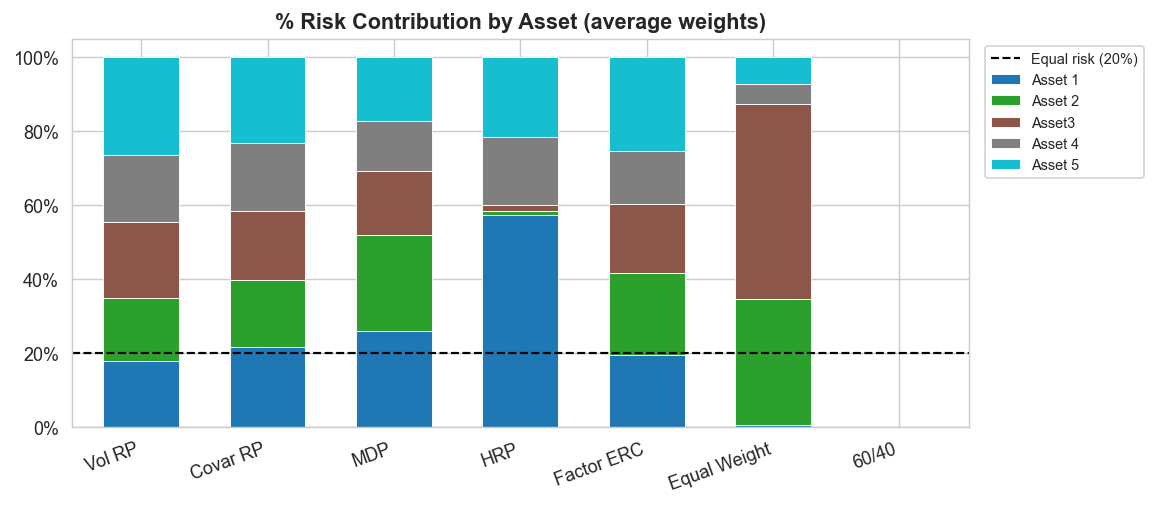

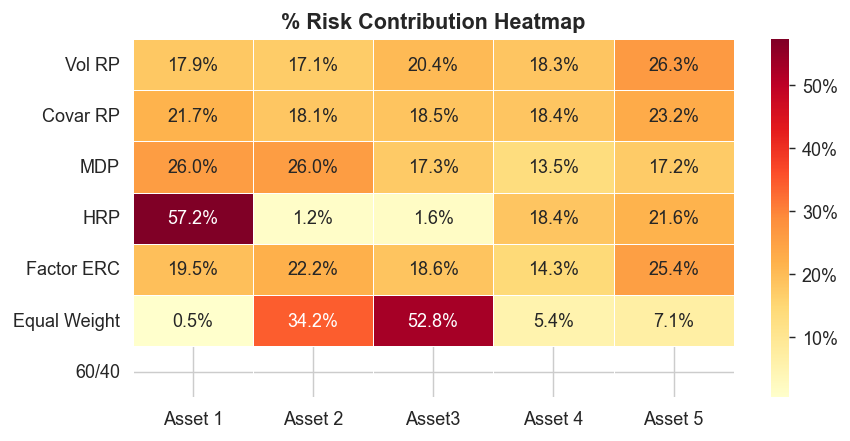

In [9]:
# Full-sample % TRC for each method (using time-average weights + full-sample cov)
trc_table = {}
for method, wdf in weights_df.items():
    w_avg = wdf.dropna().mean().values
    _, _, prc = trc_decomp(w_avg, cov_full)
    trc_table[method] = dict(zip(assets, prc))

trc_df = pd.DataFrame(trc_table).T
print('=== % Risk Contribution by Asset (time-average weights, full-sample Σ) ===')
display(trc_df.style.format('{:.1%}'))

# ── stacked bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
trc_df.plot(kind='bar', stacked=True, ax=ax, width=0.6,
            colormap='tab10', edgecolor='white', linewidth=0.5)
ax.axhline(1/N, color='black', lw=1.2, ls='--', label=f'Equal risk ({1/N:.0%})')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.set_title('% Risk Contribution by Asset (average weights)', fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.savefig('rp_trc_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# ── heatmap view ─────────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 3.5))
sns.heatmap(trc_df, annot=True, fmt='.1%', cmap='YlOrRd', ax=ax2,
            linewidths=0.5, cbar_kws={'format': mticker.PercentFormatter(1.0)})
ax2.set_title('% Risk Contribution Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('rp_trc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8 · Factor-Level TRC (Kalman Factor Model)

Portfolio factor exposure: $b_{P,k} = \sum_i w_i \beta_{i,k}$

Factor TRC:
$$\text{FTRC}_k = b_{P,k}\cdot\frac{(\Sigma_F b_P)_k}{\sigma_P^{\text{sys}}}, \qquad
\sigma_P^{\text{sys}} = \sqrt{b_P'\Sigma_F b_P}$$

Idiosyncratic share: $\dfrac{\sum_i w_i^2 \sigma_{\varepsilon,i}^2}{\sigma_P^2}$

=== Factor-Level % Risk Contribution (systematic share, average weights) ===


,Commodities,Global AGG,Gold,HF FOF Div,High Yield,Long Short HF,MSCI EM Equity,Relative Value HF,TIPs,US AGG,US Growth,US Small Cap,US Tbill 1-3yr,Idiosyncratic
Vol RP,12.0%,7.9%,1.2%,11.5%,-7.6%,4.9%,2.3%,0.7%,19.9%,17.4%,18.3%,1.0%,-0.3%,10.6%
Covar RP,11.2%,7.9%,1.4%,11.2%,-7.8%,4.4%,2.2%,0.7%,17.5%,20.5%,19.3%,1.1%,-0.3%,10.7%
MDP,9.3%,6.5%,1.5%,8.3%,-7.4%,4.1%,1.9%,0.5%,13.0%,24.2%,26.4%,1.4%,-0.4%,10.5%
HRP,4.5%,8.8%,2.5%,6.9%,-6.6%,0.5%,1.1%,0.3%,18.0%,47.8%,2.5%,0.8%,-0.2%,12.9%
Factor ERC,10.3%,6.8%,1.3%,9.3%,-6.9%,4.5%,2.0%,0.7%,19.3%,19.0%,23.2%,1.1%,-0.3%,9.8%
Equal Weight,19.2%,3.6%,0.2%,5.7%,-3.4%,12.6%,2.8%,0.4%,5.3%,1.3%,34.8%,0.3%,0.3%,16.8%
60/40,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%


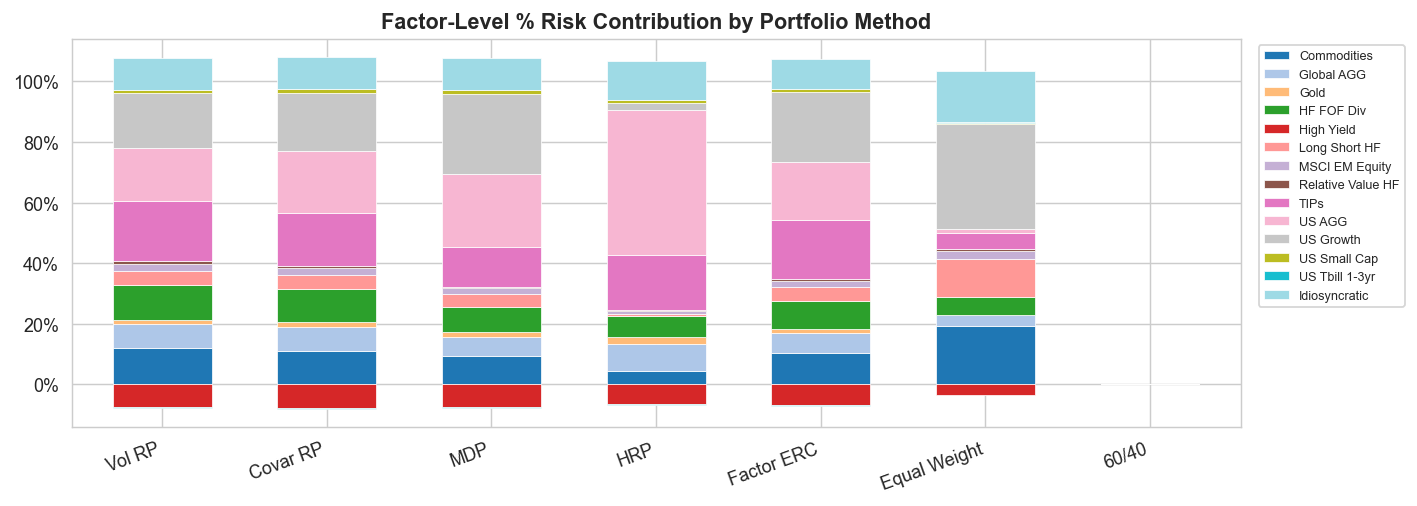

In [10]:
# Full-sample factor covariance (union factors)
Sigma_F_full = np.cov(F_all[UNION_FACTORS].values.T, ddof=0)   # (K × K)
K = len(UNION_FACTORS)

# Full-sample average betas + residual variances
B_avg       = np.zeros((N, K))      # average B matrix
resid_vars  = np.zeros(N)           # per-asset idiosyncratic variance
for i, asset in enumerate(assets):
    af = fl[asset]
    for j, factor in enumerate(UNION_FACTORS):
        if factor in af.columns:
            B_avg[i, j] = float(af[factor].mean())
    # Residuals: r_i - F_i @ beta_avg
    beta_i     = af.mean().values
    facs_i     = ASSET_FACTORS[asset]
    resid_i    = r_all[asset].values - F_all[facs_i].values @ beta_i
    resid_vars[i] = np.var(resid_i, ddof=1)


def factor_trc(w, B, Sigma_F, resid_vars, union_factors):
    """Factor-level % risk contribution + idiosyncratic share."""
    w  = np.asarray(w, dtype=float)
    bP = B.T @ w                            # (K,) portfolio factor exposure
    SFb   = Sigma_F @ bP                    # (K,)
    var_s = float(bP @ SFb)                 # systematic variance
    var_e = float((w ** 2) @ resid_vars)    # idiosyncratic variance
    var_t = max(var_s + var_e, 1e-20)
    sig_s = np.sqrt(max(var_s, 1e-20))

    ftrc_raw = bP * SFb / sig_s             # factor TRC (monthly, systematic)
    ftrc_pct = ftrc_raw / sig_s             # as fraction of systematic variance
    # Re-scale to fraction of *total* variance
    ftrc_total = ftrc_pct * (var_s / var_t)
    idio_share = var_e / var_t
    return pd.Series(ftrc_total, index=union_factors), idio_share


# Compute factor TRC for each method
ftrc_table = {}
idio_table = {}
for method, wdf in weights_df.items():
    w_avg = wdf.dropna().mean().values
    ftrc, idio = factor_trc(w_avg, B_avg, Sigma_F_full, resid_vars, UNION_FACTORS)
    ftrc_table[method] = ftrc
    idio_table[method] = idio

ftrc_df = pd.DataFrame(ftrc_table).T
ftrc_df['Idiosyncratic'] = pd.Series(idio_table)

print('=== Factor-Level % Risk Contribution (systematic share, average weights) ===')
display(ftrc_df.style.format('{:.1%}'))

# ── factor TRC bar chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
ftrc_df.plot(kind='bar', stacked=True, ax=ax, width=0.6,
             colormap='tab20', edgecolor='white', linewidth=0.4)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.set_title('Factor-Level % Risk Contribution by Portfolio Method', fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=7, ncol=1)
plt.tight_layout()
plt.savefig('rp_factor_trc.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9 · Rolling Portfolio Weights

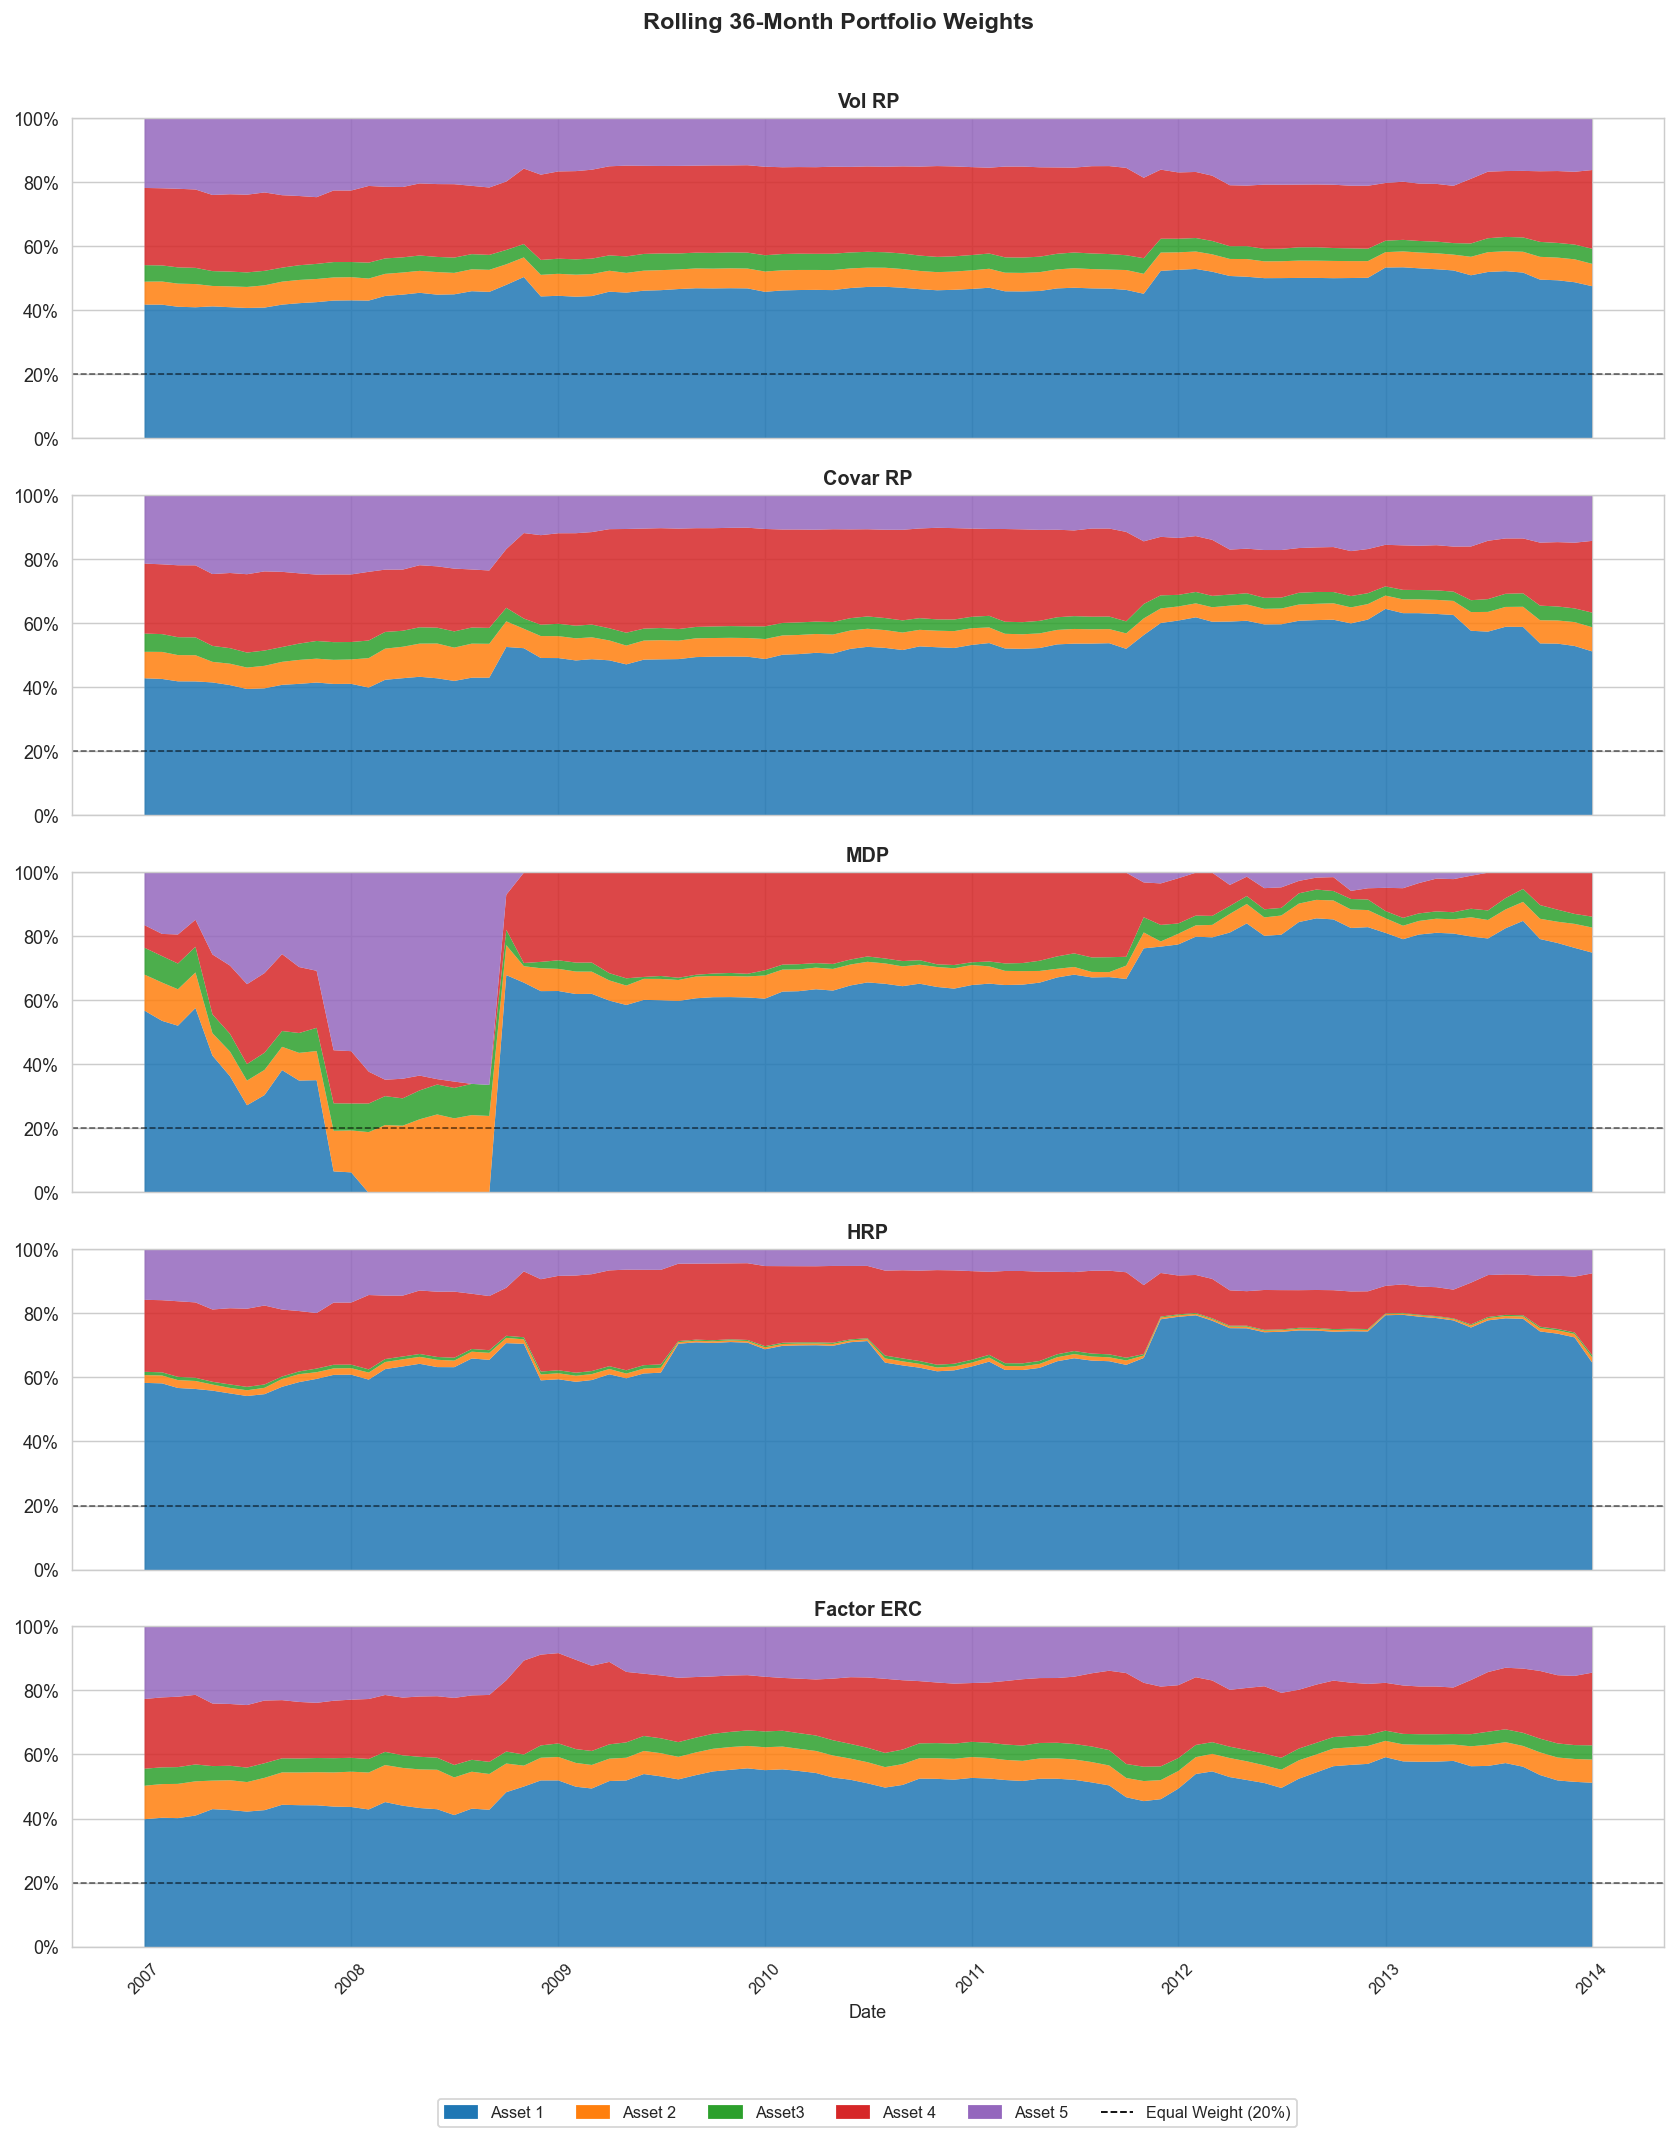

In [11]:
PLOT_METHODS = ['Vol RP', 'Covar RP', 'MDP', 'HRP', 'Factor ERC']
fig, axes = plt.subplots(len(PLOT_METHODS), 1, figsize=(13, 3.2 * len(PLOT_METHODS)),
                         sharex=True)

asset_colors = sns.color_palette('tab10', n_colors=N)

for ax, method in zip(axes, PLOT_METHODS):
    wdf = weights_df[method].dropna()
    ax.stackplot(wdf.index, wdf.values.T, colors=asset_colors, alpha=0.85, linewidth=0)
    ax.axhline(1/N, color='black', lw=0.9, ls='--', alpha=0.6, label=f'EW={1/N:.0%}')
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title(method, fontweight='bold', fontsize=11)

# Date axis: major tick = Jan each year; minor tick = every month
axes[-1].xaxis.set_major_locator(mdates.YearLocator(1, month=1, day=1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_minor_locator(mdates.MonthLocator())
axes[-1].tick_params(axis='x', which='major', labelrotation=45, labelsize=9, pad=4)
axes[-1].tick_params(axis='x', which='minor', length=3)
axes[-1].set_xlabel('Date')

handles = [plt.Rectangle((0, 0), 1, 1, color=asset_colors[i]) for i in range(N)]
handles += [plt.Line2D([0], [0], color='black', lw=1, ls='--')]
axes[-1].legend(handles, assets + ['Equal Weight (20%)'],
                loc='upper center', bbox_to_anchor=(0.5, -0.45),
                ncol=N + 1, fontsize=9)

fig.suptitle('Rolling 36-Month Portfolio Weights', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.savefig('rp_rolling_weights.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 10 · Historical Simulation: Cumulative Returns

Matches the format of the backtest chart in Class 5-3, slide 15.
Base = 100 at the start of the backtest window.

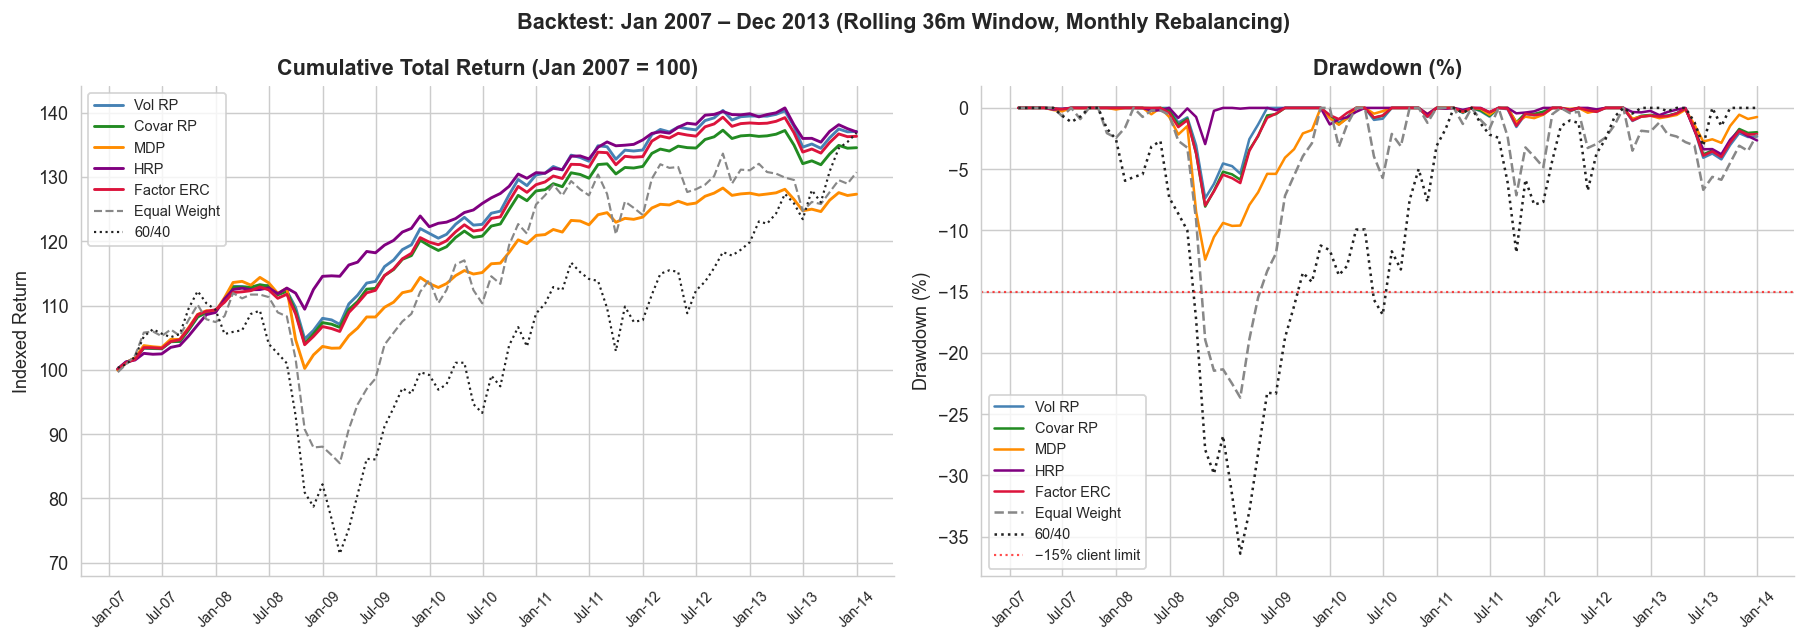

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── left: cumulative total return (indexed to 100) ────────────────────────────
ax = axes[0]
for method, rets in port_rets.items():
    cum = 100 * (1 + rets).cumprod()
    ls  = ':' if method == '60/40' else ('--' if method == 'Equal Weight' else '-')
    lw  = 1.2 if method in ('Equal Weight', '60/40') else 1.6
    ax.plot(cum.index, cum.values, label=method,
            color=COLORS[method], lw=lw, ls=ls)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.tick_params(axis='x', labelrotation=45, labelsize=8)
ax.set_title('Cumulative Total Return (Jan 2007 = 100)', fontweight='bold')
ax.set_ylabel('Indexed Return')
ax.legend(fontsize=8)
sns.despine(ax=ax)

# ── right: drawdown ───────────────────────────────────────────────────────────
ax2 = axes[1]
for method, rets in port_rets.items():
    cum  = (1 + rets).cumprod()
    peak = cum.expanding().max()
    dd   = (cum / peak - 1) * 100
    ls   = ':' if method == '60/40' else ('--' if method == 'Equal Weight' else '-')
    ax2.plot(dd.index, dd.values, label=method,
             color=COLORS[method], lw=1.4, ls=ls)

ax2.axhline(-15, color='red', lw=1.2, ls=':', alpha=0.7, label='−15% client limit')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax2.tick_params(axis='x', labelrotation=45, labelsize=8)
ax2.set_title('Drawdown (%)', fontweight='bold')
ax2.set_ylabel('Drawdown (%)')
ax2.legend(fontsize=8)
sns.despine(ax=ax2)

fig.suptitle('Backtest: Jan 2007 – Dec 2013 (Rolling 36m Window, Monthly Rebalancing)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('rp_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11 · Rolling TRC Analysis

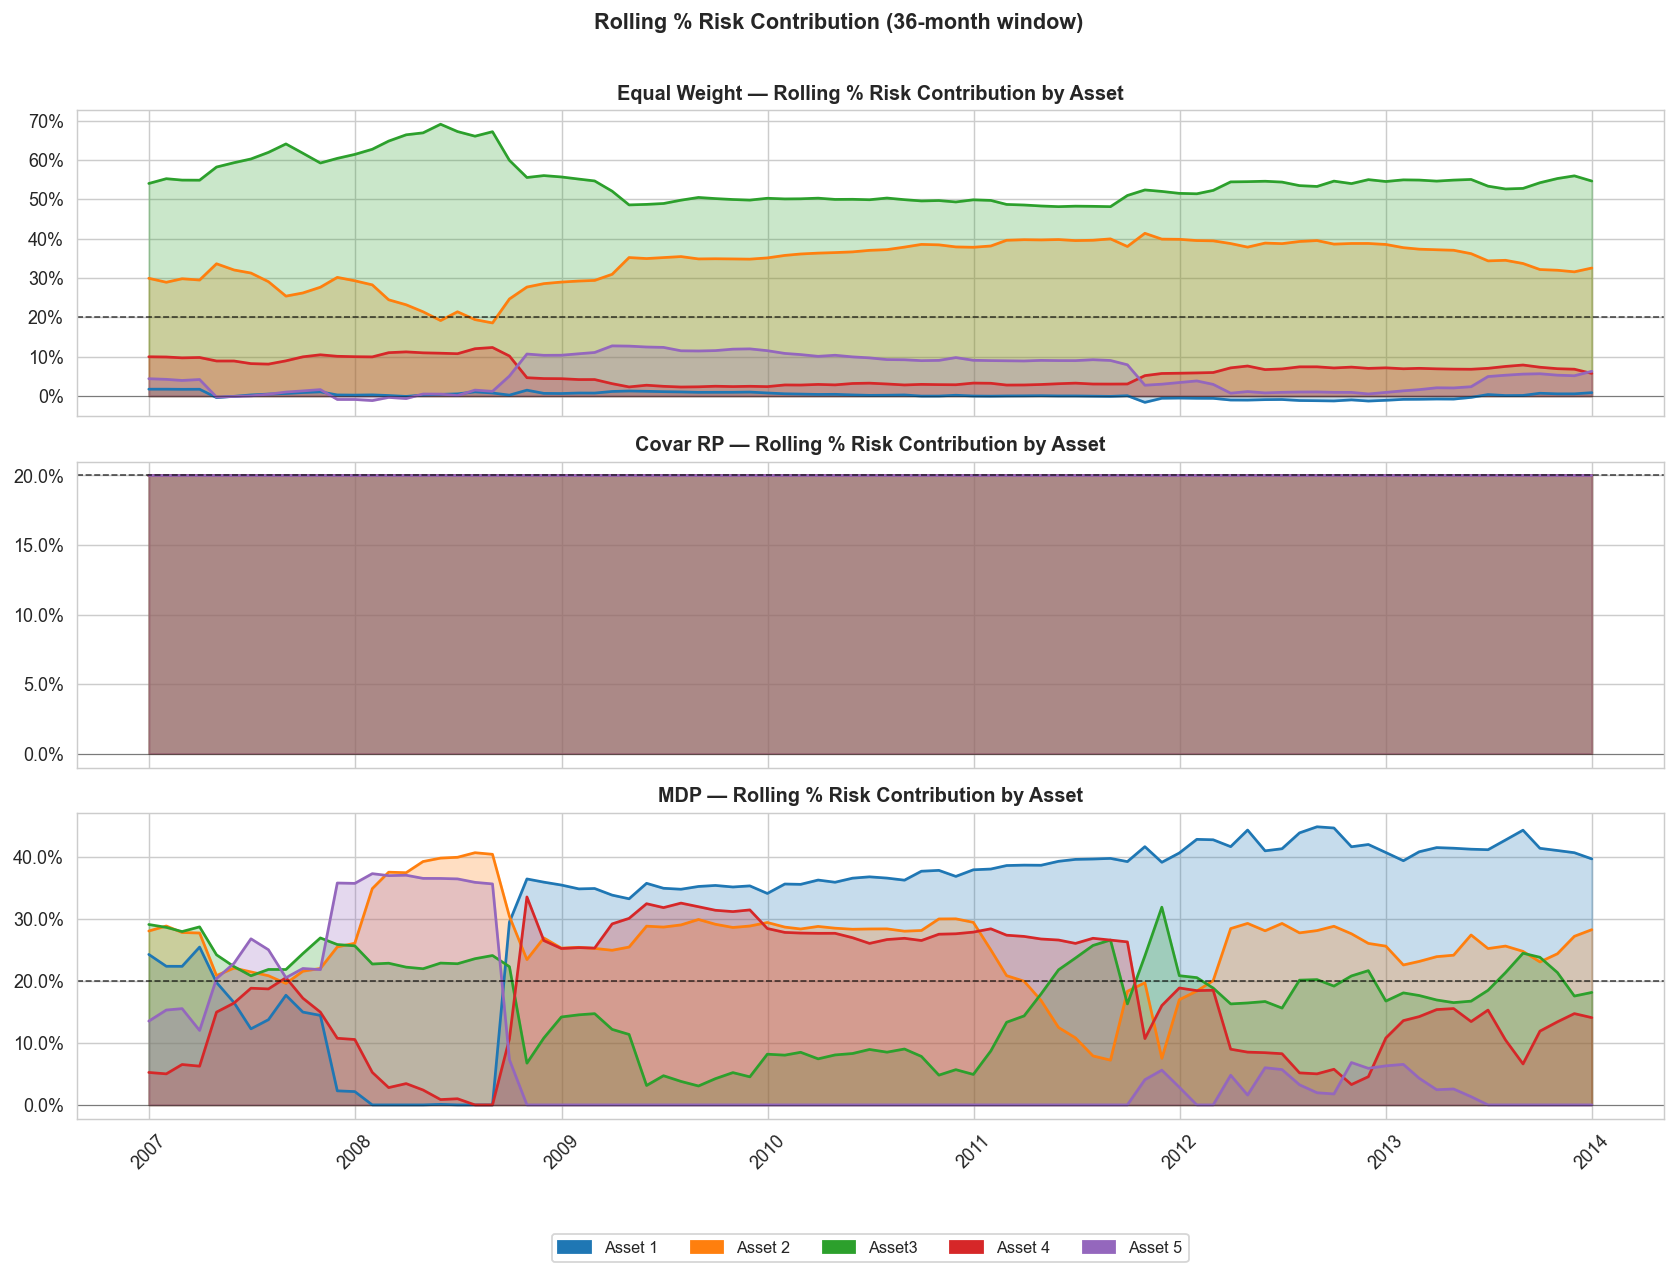

In [13]:
# Compute rolling TRC (% risk contribution) at each rebalancing date
def rolling_prc(wdf, r_all, roll_win=ROLL_WIN):
    """Returns DataFrame of % TRC by asset at each date."""
    T = len(wdf)
    records = []
    for t in range(roll_win - 1, T):
        t_s  = t - roll_win + 1
        cov  = np.cov(r_all.iloc[t_s:t+1].values.T, ddof=0)
        w    = wdf.iloc[t].values
        if np.isnan(w).any():
            continue
        _, _, prc = trc_decomp(w, cov)
        row = dict(zip(r_all.columns, prc))
        row['Date'] = wdf.index[t]
        records.append(row)
    return pd.DataFrame(records).set_index('Date')


TRC_METHODS = ['Equal Weight', 'Covar RP', 'MDP']
fig, axes = plt.subplots(len(TRC_METHODS), 1, figsize=(13, 3.2 * len(TRC_METHODS)),
                         sharex=True)

for ax, method in zip(axes, TRC_METHODS):
    prc_ts = rolling_prc(weights_df[method], r_all)
    for j, col in enumerate(prc_ts.columns):
        ax.plot(prc_ts.index, prc_ts[col], color=asset_colors[j], lw=1.5)
        ax.fill_between(prc_ts.index, prc_ts[col], 0,
                        color=asset_colors[j], alpha=0.25)
    ax.axhline(1/N, color='black', lw=0.9, ls='--', alpha=0.7)
    ax.axhline(0,   color='black', lw=0.6, alpha=0.4)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title(f'{method} — Rolling % Risk Contribution by Asset',
                 fontweight='bold', fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.tick_params(axis='x', labelrotation=45)

handles = [plt.Rectangle((0, 0), 1, 1, color=asset_colors[i]) for i in range(N)]
axes[-1].legend(handles, assets,
                loc='upper center', bbox_to_anchor=(0.5, -0.35),
                ncol=N, fontsize=9)
fig.suptitle('Rolling % Risk Contribution (36-month window)', fontsize=12,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('rp_rolling_trc.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12 · Final Snapshot: End-of-Sample Portfolio Weights & Risk Profile

Weights computed using data through **December 2013** (full sample) — this is the
proposed forward allocation for the client.

=== End-of-Sample Proposed Weights (using last 36m Σ) ===


,Asset 1,Asset 2,Asset3,Asset 4,Asset 5
Method,,,,,
Equal Weight,20.0%,20.0%,20.0%,20.0%,20.0%
Vol RP,47.7%,7.0%,4.7%,24.6%,16.1%
Covar RP,51.4%,7.6%,4.6%,22.4%,14.1%
MDP,75.0%,7.8%,3.4%,13.7%,0.0%
HRP,64.8%,1.6%,0.7%,25.5%,7.4%
Factor ERC,51.3%,7.2%,4.4%,22.7%,14.3%



=== End-of-Sample % Risk Contribution ===


,Asset 1,Asset 2,Asset3,Asset 4,Asset 5
Method,,,,,
Equal Weight,0.8%,32.5%,54.6%,5.7%,6.3%
Vol RP,18.2%,17.3%,20.0%,21.8%,22.6%
Covar RP,20.0%,20.0%,20.0%,20.0%,20.0%
MDP,39.6%,28.2%,18.1%,14.1%,0.0%
HRP,48.4%,1.8%,1.8%,31.7%,16.3%
Factor ERC,20.5%,18.8%,19.4%,20.6%,20.7%



=== End-of-Sample Risk/Return Profile ===


,Ann. Return (est.),Ann. Vol (est.),Sharpe (est.),Div. Ratio,TE to EW (est.)
Method,,,,,
Equal Weight,1.55%,6.93%,0.081,1.350,0.00%
Vol RP,1.89%,3.13%,0.290,1.562,4.58%
Covar RP,2.04%,3.05%,0.345,1.574,4.59%
MDP,2.34%,2.40%,0.562,1.616,5.09%
HRP,1.63%,2.29%,0.280,1.384,6.08%
Factor ERC,2.01%,3.02%,0.337,1.572,4.65%


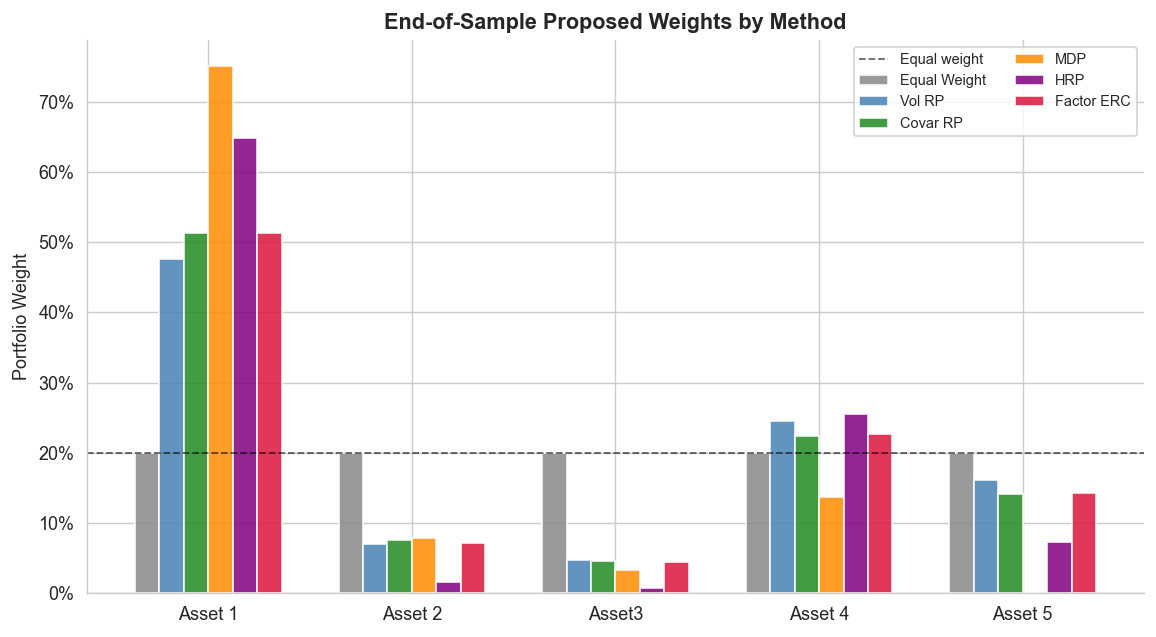

In [14]:
# End-of-sample (Dec 2013) portfolio weights
final_cov = np.cov(r_all.values.T, ddof=0)  # full-sample population cov
last36_cov = np.cov(r_all.iloc[-ROLL_WIN:].values.T, ddof=0)

final_w = {
    'Equal Weight' : EQ_W,
    'Vol RP'       : vol_rp(last36_cov),
    'Covar RP'     : erc_portfolio(last36_cov),
    'MDP'          : mdp_portfolio(last36_cov),
    'HRP'          : hrp_portfolio(last36_cov),
    'Factor ERC'   : factor_erc_portfolio(
                         T - 1, fl, assets, ASSET_FACTORS, UNION_FACTORS,
                         F_all, r_all, ROLL_WIN),
}

# Build full snapshot table
rows = []
for method, w in final_w.items():
    sig_m, trc_m, prc = trc_decomp(w, last36_cov)
    mu_m    = w @ r_all.iloc[-ROLL_WIN:].mean().values
    sig_ann = sig_m * np.sqrt(ANN)
    mu_ann  = mu_m  * ANN
    dr      = w @ np.sqrt(np.diag(last36_cov)) / sig_m   # diversification ratio
    te_ann = np.sqrt((w - EQ_W) @ last36_cov @ (w - EQ_W)) * np.sqrt(ANN)
    row = {'Method': method,
           'Ann. Return (est.)': mu_ann,
           'Ann. Vol (est.)'   : sig_ann,
           'Sharpe (est.)'     : (mu_ann - rf_mean) / sig_ann,
           'Div. Ratio'        : dr,
           'TE to EW (est.)'   : te_ann}
    for i, a in enumerate(assets):
        row[f'w_{a}'] = w[i]
        row[f'PRC_{a}'] = prc[i]
    rows.append(row)

snap = pd.DataFrame(rows).set_index('Method')

# ── weights table ─────────────────────────────────────────────────────────────
w_cols  = [f'w_{a}' for a in assets]
prc_cols = [f'PRC_{a}' for a in assets]

print('=== End-of-Sample Proposed Weights (using last 36m Σ) ===')
display(snap[w_cols].rename(columns={f'w_{a}': a for a in assets})
             .style.format('{:.1%}'))

print('\n=== End-of-Sample % Risk Contribution ===')
display(snap[prc_cols].rename(columns={f'PRC_{a}': a for a in assets})
             .style.format('{:.1%}'))

print('\n=== End-of-Sample Risk/Return Profile ===')
stat_cols = ['Ann. Return (est.)', 'Ann. Vol (est.)', 'Sharpe (est.)', 'Div. Ratio', 'TE to EW (est.)']
display(snap[stat_cols].style.format({
    'Ann. Return (est.)':'{:.2%}',
    'Ann. Vol (est.)'   :'{:.2%}',
    'Sharpe (est.)'     :'{:.3f}',
    'Div. Ratio'        :'{:.3f}',
    'TE to EW (est.)'   :'{:.2%}',
}))

# ── radar/spider chart: final weights comparison ─────────────────────────────
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(N)
bar_w = 0.12
method_list = list(final_w.keys())
for k, method in enumerate(method_list):
    bars = ax.bar(x + k * bar_w - bar_w * (len(method_list)/2 - 0.5),
                  final_w[method], bar_w, label=method,
                  color=COLORS[method], alpha=0.85, edgecolor='white')

ax.axhline(1/N, color='black', lw=1, ls='--', alpha=0.6, label='Equal weight')
ax.set_xticks(x)
ax.set_xticklabels(assets)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('End-of-Sample Proposed Weights by Method', fontweight='bold')
ax.set_ylabel('Portfolio Weight')
ax.legend(fontsize=8, ncol=2)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('rp_final_weights.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 13 · Summary Comparison Table (Project Page 5)

Presents all metrics needed for the **RP Proposal slide**.

In [15]:
# Merge backtest performance + end-of-sample stats into one table
rows_final = []
for method in METHODS:
    if method not in final_w:          # skip benchmarks with no RP weights (e.g. 60/40)
        continue
    rets = port_rets[method]
    pm   = perf_metrics(rets, rf_mean)
    w_e  = final_w[method]
    sig_m_e, _, prc_e = trc_decomp(w_e, last36_cov)
    active = rets - port_rets['Equal Weight']
    te     = active.std() * np.sqrt(ANN)

    rows_final.append({
        'Method'           : method,
        # Backtest
        'Ret (bt)'         : pm['Ann. Return'],
        'Vol (bt)'         : pm['Ann. Vol'],
        'Sharpe (bt)'      : pm['Sharpe'],
        'MaxDD (bt)'       : pm['Max DD'],
        'TE vs EW'         : te,
        # End-of-sample
        'Proposed σ (ann)' : sig_m_e * np.sqrt(ANN),
        'Largest PRC'      : prc_e.max(),
        'Min PRC'          : prc_e.min(),
    })

summary_final = pd.DataFrame(rows_final).set_index('Method')
print('=== Complete RP Proposal Summary (Page 5) ===')
display(summary_final.style.format({
    'Ret (bt)'         : '{:.2%}',
    'Vol (bt)'         : '{:.2%}',
    'Sharpe (bt)'      : '{:.3f}',
    'MaxDD (bt)'       : '{:.2%}',
    'TE vs EW'         : '{:.2%}',
    'Proposed σ (ann)' : '{:.2%}',
    'Largest PRC'      : '{:.1%}',
    'Min PRC'          : '{:.1%}',
}).highlight_max(subset=['Sharpe (bt)'], color='lightgreen')
 .highlight_min(subset=['Vol (bt)', 'MaxDD (bt)', 'Largest PRC'], color='lightyellow'))

# ── key insight summary ───────────────────────────────────────────────────────
best_sharpe = summary_final['Sharpe (bt)'].idxmax()
lowest_dd   = summary_final['MaxDD (bt)'].idxmax()    # least negative = closest to 0
most_equal  = summary_final['Largest PRC'].idxmin()   # smallest max PRC = most balanced
print(f'\nKey findings:')
print(f'  Highest Sharpe   : {best_sharpe} '
      f'({summary_final.loc[best_sharpe,"Sharpe (bt)"]:.3f})')
print(f'  Smallest Max DD  : {lowest_dd} '
      f'({summary_final.loc[lowest_dd,"MaxDD (bt)"]:.2%})')
print(f'  Most balanced TRC: {most_equal} '
      f'(largest PRC = {summary_final.loc[most_equal,"Largest PRC"]:.1%})')
print(f'\nNote: Equal Weight has largest PRC = {summary_final.loc["Equal Weight","Largest PRC"]:.1%} '
      f'(risk concentrated, NOT diversified)')

=== Complete RP Proposal Summary (Page 5) ===


,Ret (bt),Vol (bt),Sharpe (bt),MaxDD (bt),TE vs EW,Proposed σ (ann),Largest PRC,Min PRC
Method,,,,,,,,
Vol RP,4.59%,3.97%,0.909,-7.38%,6.13%,3.13%,22.6%,17.3%
Covar RP,4.32%,3.86%,0.864,-8.06%,6.31%,3.05%,20.0%,20.0%
MDP,3.56%,4.46%,0.576,-12.39%,6.61%,2.40%,39.6%,0.0%
HRP,4.55%,2.87%,1.239,-3.79%,8.21%,2.29%,48.4%,1.8%
Factor ERC,4.51%,3.85%,0.916,-7.97%,6.19%,3.02%,20.7%,18.8%
Equal Weight,4.25%,9.14%,0.357,-23.66%,0.00%,6.93%,54.6%,0.8%



Key findings:
  Highest Sharpe   : HRP (1.239)
  Smallest Max DD  : HRP (-3.79%)
  Most balanced TRC: Covar RP (largest PRC = 20.0%)

Note: Equal Weight has largest PRC = 54.6% (risk concentrated, NOT diversified)
